marking weekends based on AQI

In [5]:
import pandas as pd 
import numpy as np

df = pd.read_csv("C:\\Users\\hp\\OneDrive\\Desktop\\China-Air-pollution-Analysis\\China-Air-pollution-Analysis\\cleaned_pollution_weather.csv")

In [20]:
df.columns

Index(['date', 'provorg', 'avg_aqi', 'temp', 'wdsp', 'prcp', 'visib', 'year',
       'month', 'day_of_week', 'is_weekend', 'avg_aqi_lag1', 'rolling_avg_aqi',
       'pollution_category', 'high_pollution_flag', 'zscore_aqi', 'is_outlier',
       'regional_avg_aqi', 'regional_pollution_rank'],
      dtype='object')

In [6]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek  # 0 = Monday, 6 = Sunday
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)  # 1 if Sat/Sun, else 0
df.head


# This is used to say and analyse Is pollution higher on weekdays due to traffic

<bound method NDFrame.head of            date   provorg    avg_aqi       temp      wdsp      prcp  \
0    2018-01-25     Anhui  30.621572   4.100340  3.085879  0.283590   
1    2018-01-26     Anhui  34.467580   4.100340  3.085879  0.283590   
2    2018-01-27     Anhui  34.258030   4.100340  3.085879  0.283590   
3    2018-01-28     Anhui  56.709930   4.100340  3.085879  0.283590   
4    2018-01-29     Anhui  87.794530   4.100340  3.085879  0.283590   
...         ...       ...        ...        ...       ...       ...   
4645 2020-02-17  Zhejiang  23.002382  10.375653  2.977650  0.289409   
4646 2020-02-18  Zhejiang  24.461900  10.375653  2.977650  0.289409   
4647 2020-02-19  Zhejiang  26.993467  10.375653  2.977650  0.289409   
4648 2020-02-20  Zhejiang  27.372845  10.375653  2.977650  0.289409   
4649 2020-02-21  Zhejiang  24.515009  10.375653  2.977650  0.289409   

          visib  year  month  day_of_week  is_weekend  
0      9.486073  2018      1            3           0  
1    

Logistic Regression for weekend detection

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np

features = ['temp', 'wdsp', 'prcp', 'visib', 'avg_aqi', 'avg_aqi_lag1',
            'rolling_avg_aqi', 'regional_avg_aqi']

X = df[features]
y = df['is_weekend']  

In [29]:
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

In [41]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

unique, counts = np.unique(y_pred, return_counts=True)
print("\n Prediction Distribution:", dict(zip(unique, counts)))

results_df = pd.DataFrame({
    'date': df.loc[y_test.index, 'date'].values,
    'Actual_is_weekend': y_test.values,
    'Predicted_is_weekend': y_pred
})

# Show where model predicted weekend = 1
print("\n Model Predicted These as Weekends:")
print(results_df[results_df['Predicted_is_weekend'] == 1].head(10))


 Accuracy: 0.5236559139784946

 Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.53      0.62       670
           1       0.29      0.50      0.37       260

    accuracy                           0.52       930
   macro avg       0.51      0.52      0.49       930
weighted avg       0.61      0.52      0.55       930


 Confusion Matrix:
 [[356 314]
 [129 131]]

 Prediction Distribution: {0: 485, 1: 445}

 Model Predicted These as Weekends:
         date  Actual_is_weekend  Predicted_is_weekend
0  2018-02-10                  1                     1
1  2020-02-15                  1                     1
2  2018-02-11                  1                     1
3  2018-02-28                  0                     1
4  2020-02-02                  1                     1
6  2020-02-03                  0                     1
8  2020-02-16                  1                     1
9  2020-01-05                  1                   

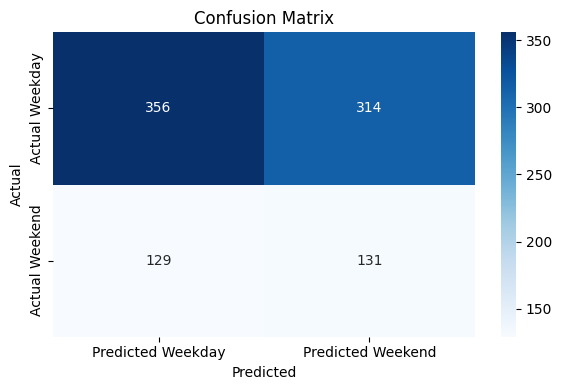

In [42]:
# Actual vs Predicted weekends
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Weekday', 'Predicted Weekend'],
            yticklabels=['Actual Weekday', 'Actual Weekend'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()




Using Linear- Regression to find outliers from the data using the aqi and pollution level 

In [23]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

features = ['temp', 'wdsp', 'prcp', 'visib', 'is_weekend', 'day_of_week', 
            'avg_aqi_lag1', 'rolling_avg_aqi', 'regional_avg_aqi']

X = df[features]
y = df['avg_aqi']

imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [25]:
# METRICS OF OUR LINEAR REGRESSION MODEL:

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Model Evaluation Metrics:
Mean Absolute Error (MAE): 8.24
Root Mean Squared Error (RMSE): 11.92
R-squared (R²): 0.65


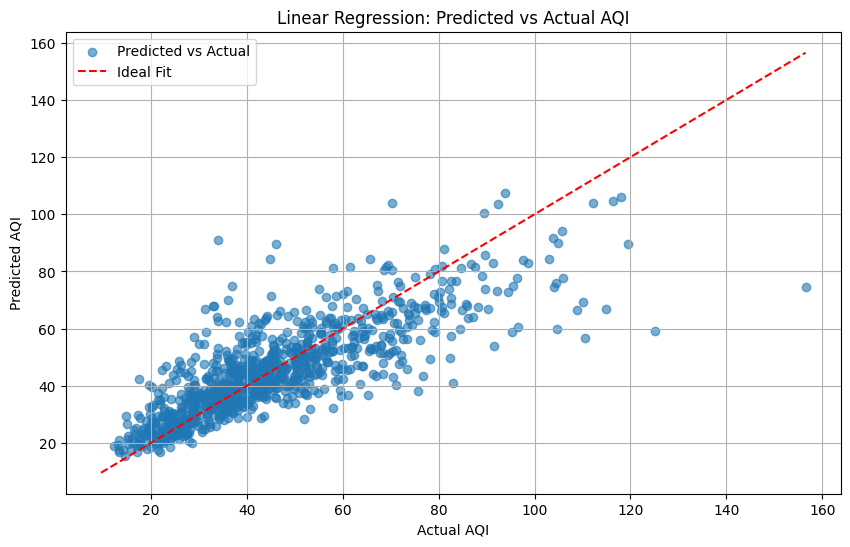

In [26]:
# predicyted vs actual aqi using linear regression 

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label='Predicted vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Ideal Fit')
plt.title('Linear Regression: Predicted vs Actual AQI')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.legend()
plt.grid(True)
plt.show()

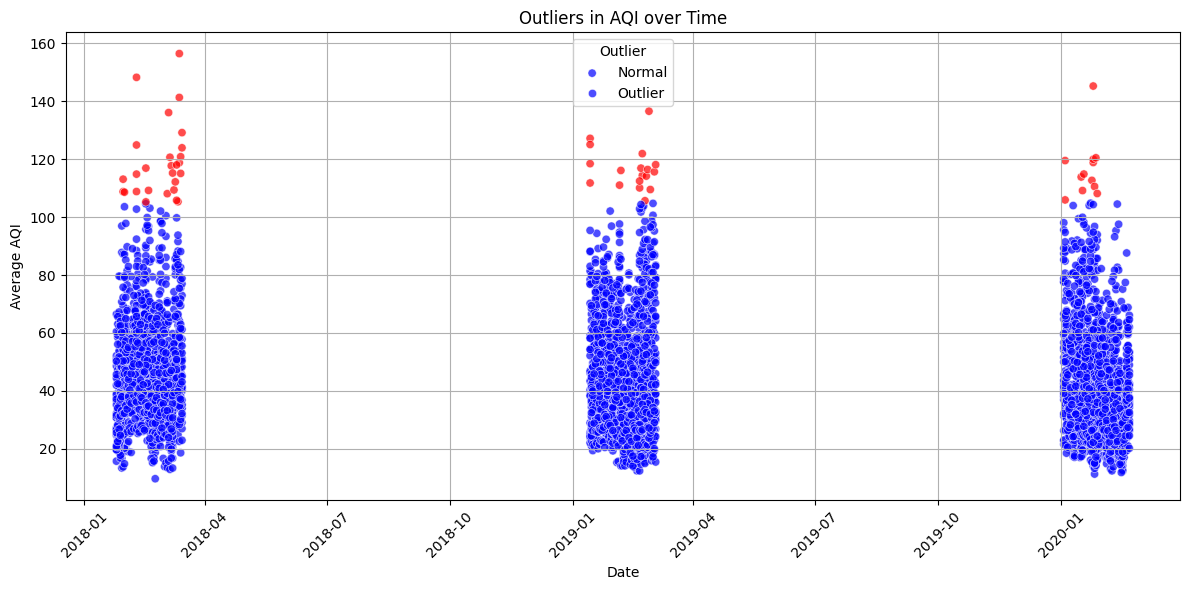

In [ ]:
# Weekend Identification using Linear Regression

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='date', y='avg_aqi', hue='is_outlier', palette={0: 'blue', 1: 'red'}, alpha=0.7)
plt.title('Outliers in AQI over Time')
plt.xlabel('Date')
plt.ylabel('Average AQI')
plt.legend(title='Outlier', labels=['Normal', 'Outlier'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

In [9]:
#EFFECT OF POLLUTION IN THE PAST ON THE FUTURE 
# first we calculate previous day aqi and find the next week average 
df['avg_aqi_lag1'] = df['avg_aqi'].shift(1) 
df['rolling_avg_aqi'] = df['avg_aqi'].rolling(window=7).mean()  

df.head()


,date,provorg,avg_aqi,temp,wdsp,prcp,visib,year,month,day_of_week,is_weekend,avg_aqi_lag1,rolling_avg_aqi
0,2018-01-25,Anhui,30.621572,4.10034,3.085879,0.28359,9.486073,2018,1,3,0,NaN,NaN
1,2018-01-26,Anhui,34.467580,4.10034,3.085879,0.28359,9.486073,2018,1,4,0,30.621572,NaN
2,2018-01-27,Anhui,34.258030,4.10034,3.085879,0.28359,9.486073,2018,1,5,1,34.467580,NaN
3,2018-01-28,Anhui,56.709930,4.10034,3.085879,0.28359,9.486073,2018,1,6,1,34.258030,NaN
4,2018-01-29,Anhui,87.794530,4.10034,3.085879,0.28359,9.486073,2018,1,0,0,56.709930,NaN


Calculating The Future values based on past and groups sismilar weeks using Linear Regression + Clustering(K-Mean)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [7]:
df['avg_aqi_lag1'] = df['avg_aqi'].shift(1)

df['next_week_avg_aqi'] = df['avg_aqi'].shift(-7).rolling(window=7).mean()

df_clean = df.dropna(subset=['avg_aqi_lag1', 'next_week_avg_aqi'])


In [8]:
X = df_clean[['avg_aqi_lag1']].values
y = df_clean['next_week_avg_aqi'].values

In [9]:
lr_model = LinearRegression()
lr_model.fit(X, y)
y_pred = lr_model.predict(X)

# Evaluation
print("Linear Regression Metrics:")
print("R² Score:", r2_score(y, y_pred))
print("MSE:", mean_squared_error(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))

Linear Regression Metrics:
R² Score: 0.3379251069635937
MSE: 170.82295252302802
RMSE: 13.069925497990722


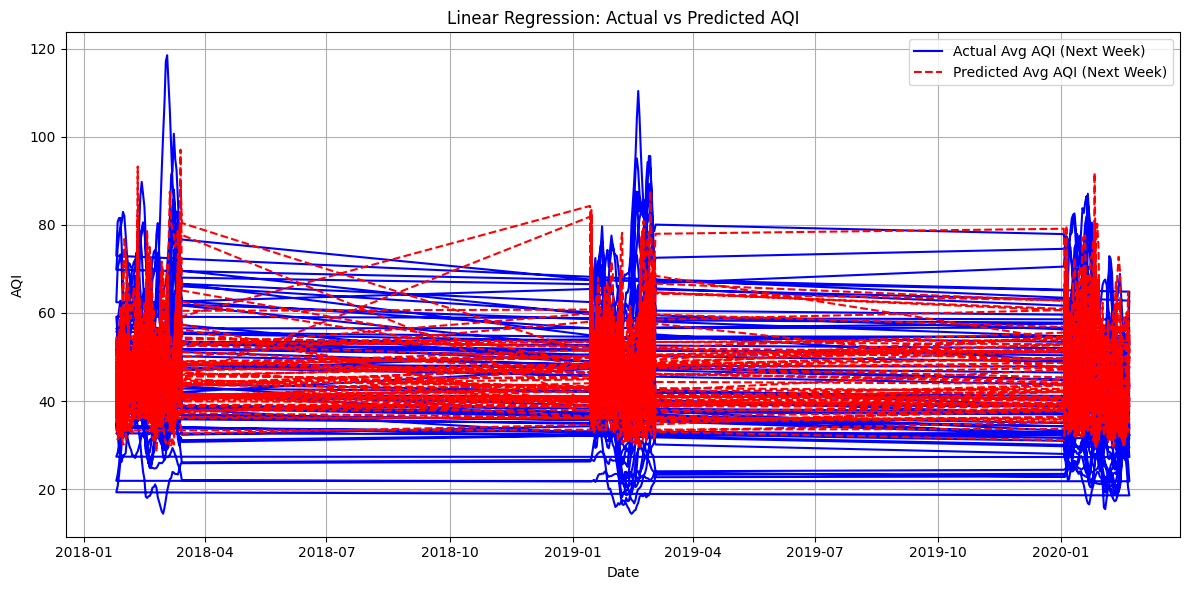

In [10]:
# Ensure 'date' column is datetime
df['date'] = pd.to_datetime(df['date'])

# Shift and compute lagged AQI and target
df['avg_aqi_lag1'] = df['avg_aqi'].shift(1)
df['next_week_avg_aqi'] = df['avg_aqi'].shift(-7).rolling(window=7).mean()

# Drop NA values
df_clean = df.dropna(subset=['avg_aqi_lag1', 'next_week_avg_aqi'])

# Features and target
X = df_clean[['avg_aqi_lag1']].values
y = df_clean['next_week_avg_aqi'].values

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X, y)
y_pred = lr_model.predict(X)

# Plot with proper x-axis
plt.figure(figsize=(12, 6))
plt.plot(df_clean['date'], y, label='Actual Avg AQI (Next Week)', color='blue')
plt.plot(df_clean['date'], y_pred, label='Predicted Avg AQI (Next Week)', color='red', linestyle='--')
plt.title('Linear Regression: Actual vs Predicted AQI')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\hp\AppData\Local\Temp\ipykernel_21836\896278912.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['cluster'] = kmeans.fit_predict(weekly_scaled)


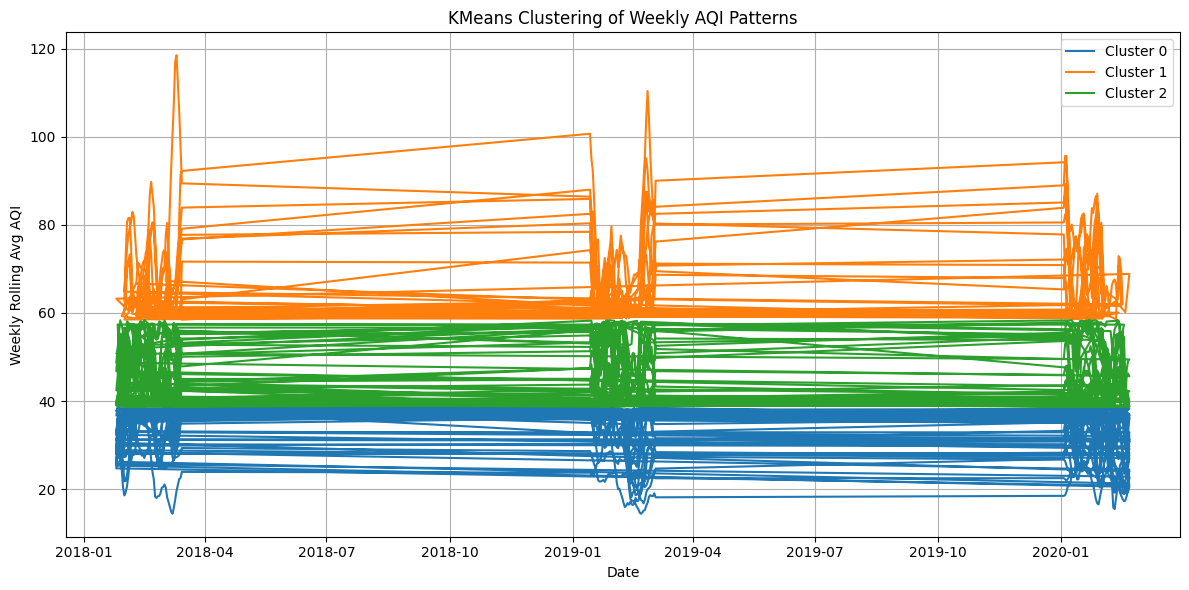

In [11]:
# Ensure 'date' column is datetime
df['date'] = pd.to_datetime(df['date'])

# Create weekly rolling average
df['weekly_avg_aqi'] = df['avg_aqi'].rolling(window=7).mean()

# Drop NA
df_clean = df.dropna(subset=['weekly_avg_aqi'])

# Feature scaling and clustering
scaler = StandardScaler()
weekly_scaled = scaler.fit_transform(df_clean[['weekly_avg_aqi']])
kmeans = KMeans(n_clusters=3, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(weekly_scaled)

# Plot with actual dates
plt.figure(figsize=(12, 6))
for cluster in sorted(df_clean['cluster'].unique()):
    cluster_data = df_clean[df_clean['cluster'] == cluster]
    plt.plot(cluster_data['date'], cluster_data['weekly_avg_aqi'], label=f'Cluster {cluster}')

plt.title('KMeans Clustering of Weekly AQI Patterns')
plt.xlabel('Date')
plt.ylabel('Weekly Rolling Avg AQI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Marking AQI into good average and bad 

In [10]:
df['pollution_category'] = pd.cut(df['avg_aqi'], bins=[0, 50, 100, 200, 300, 500], 
                                  labels=['Good', 'Moderate', 'Unhealthy', 'Very Unhealthy', 'Hazardous'])
df['high_pollution_flag'] = (df['avg_aqi'] > 150).astype(int)  # 1 if AQI > 150, else 0


In [15]:
#OUTLIER DETECTION 

from scipy import stats
import numpy as np
# here we use z-score to find outliers
z_scores = np.abs(stats.zscore(df["avg_aqi"]))

outliers = df[z_scores > 3]
print(outliers)



           date         provorg     avg_aqi       temp      wdsp      prcp  \
197  2018-03-13         Beijing  118.816450   7.917563  2.504183  0.025400   
198  2018-03-14         Beijing  115.103690   7.917563  2.504183  0.025400   
615  2018-02-09           Gansu  124.922844  -4.431424  2.851988  0.105056   
649  2018-03-15           Gansu  123.946990   7.008176  3.238397  0.024727   
1396 2018-03-12           Hebei  105.316510   6.961538  2.719005  0.013551   
1397 2018-03-13           Hebei  141.339430   6.961538  2.719005  0.013551   
1398 2018-03-14           Hebei  120.872450   6.961538  2.719005  0.013551   
1400 2019-01-14           Hebei  127.212980   6.961538  2.719005  0.013551   
1437 2019-02-20           Hebei  110.093500  -2.923535  2.323574  0.016208   
1439 2019-02-22           Hebei  114.364460  -2.923535  2.323574  0.016208   
1594 2019-02-27    Heilongjiang  136.589130 -11.108465  3.185968  0.126910   
1595 2019-02-28    Heilongjiang  109.530410 -11.108465  3.185968

,date,provorg,avg_aqi,temp,wdsp,prcp,visib,year,month,day_of_week,is_weekend,avg_aqi_lag1,rolling_avg_aqi,pollution_category,high_pollution_flag,zscore_aqi,is_outlier,regional_avg_aqi,regional_pollution_rank
0,2018-01-25,Anhui,30.621572,4.100340,3.085879,0.283590,9.486073,2018,1,3,0,NaN,NaN,Good,0,-0.716694,0,49.559557,10.0
1,2018-01-26,Anhui,34.467580,4.100340,3.085879,0.283590,9.486073,2018,1,4,0,30.621572,NaN,Good,0,-0.524297,0,49.559557,10.0
2,2018-01-27,Anhui,34.258030,4.100340,3.085879,0.283590,9.486073,2018,1,5,1,34.467580,NaN,Good,0,-0.534780,0,49.559557,10.0
3,2018-01-28,Anhui,56.709930,4.100340,3.085879,0.283590,9.486073,2018,1,6,1,34.258030,NaN,Moderate,0,0.588379,0,49.559557,10.0
4,2018-01-29,Anhui,87.794530,4.100340,3.085879,0.283590,9.486073,2018,1,0,0,56.709930,NaN,Moderate,0,2.143389,0,49.559557,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4645,2020-02-17,Zhejiang,23.002382,10.375653,2.977650,0.289409,11.757263,2020,2,0,0,18.863080,19.416648,Good,0,-1.097845,0,36.197237,23.0
4646,2020-02-18,Zhejiang,24.461900,10.375653,2.977650,0.289409,11.757263,2020,2,1,0,23.002382,19.151280,Good,0,-1.024832,0,36.197237,23.0
4647,2020-02-19,Zhejiang,26.993467,10.375653,2.977650,0.289409,11.757263,2020,2,2,0,24.461900,19.799784,Good,0,-0.898191,0,36.197237,23.0
4648,2020-02-20,Zhejiang,27.372845,10.375653,2.977650,0.289409,11.757263,2020,2,3,0,26.993467,21.014330,Good,0,-0.879212,0,36.197237,23.0


In [14]:
# Region based AQI 

df['regional_avg_aqi'] = df.groupby('provorg')['avg_aqi'].transform('mean')
df['regional_pollution_rank'] = df['regional_avg_aqi'].rank(method='dense', ascending=False)

df


,date,provorg,avg_aqi,temp,wdsp,prcp,visib,year,month,day_of_week,is_weekend,avg_aqi_lag1,rolling_avg_aqi,pollution_category,high_pollution_flag,zscore_aqi,is_outlier,regional_avg_aqi,regional_pollution_rank
0,2018-01-25,Anhui,30.621572,4.100340,3.085879,0.283590,9.486073,2018,1,3,0,NaN,NaN,Good,0,-0.716694,0,49.559557,10.0
1,2018-01-26,Anhui,34.467580,4.100340,3.085879,0.283590,9.486073,2018,1,4,0,30.621572,NaN,Good,0,-0.524297,0,49.559557,10.0
2,2018-01-27,Anhui,34.258030,4.100340,3.085879,0.283590,9.486073,2018,1,5,1,34.467580,NaN,Good,0,-0.534780,0,49.559557,10.0
3,2018-01-28,Anhui,56.709930,4.100340,3.085879,0.283590,9.486073,2018,1,6,1,34.258030,NaN,Moderate,0,0.588379,0,49.559557,10.0
4,2018-01-29,Anhui,87.794530,4.100340,3.085879,0.283590,9.486073,2018,1,0,0,56.709930,NaN,Moderate,0,2.143389,0,49.559557,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4645,2020-02-17,Zhejiang,23.002382,10.375653,2.977650,0.289409,11.757263,2020,2,0,0,18.863080,19.416648,Good,0,-1.097845,0,36.197237,23.0
4646,2020-02-18,Zhejiang,24.461900,10.375653,2.977650,0.289409,11.757263,2020,2,1,0,23.002382,19.151280,Good,0,-1.024832,0,36.197237,23.0
4647,2020-02-19,Zhejiang,26.993467,10.375653,2.977650,0.289409,11.757263,2020,2,2,0,24.461900,19.799784,Good,0,-0.898191,0,36.197237,23.0
4648,2020-02-20,Zhejiang,27.372845,10.375653,2.977650,0.289409,11.757263,2020,2,3,0,26.993467,21.014330,Good,0,-0.879212,0,36.197237,23.0


# EMMISION OVER TIME 

In [17]:
df_cems = pd.read_csv("C:\\Users\\hp\\OneDrive\\Desktop\\China-Air-pollution-Analysis\\China-Air-pollution-Analysis\\cleaned_cems.csv")

In [19]:
df_cems.columns

Index(['firm_name', 'pollutant_x', 'time_x', 'concentration', 'provorg', 'dow',
       'proven', 'date', 'time_y', 'year_x', 'nfirms_x', 'pollutant_y',
       'provid_x', 'time', 'year_y', 'nfirms_y', 'pollutant', 'provid_y'],
      dtype='object')